In [28]:
import pandas as pd

import optuna
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import History
# this util is great! allows us to use a keras model with sklearn stuff
# basically gives our model fit() and predict() methods
from keras.wrappers import SKLearnClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

import matplotlib.pyplot as plt
from itertools import product

In [2]:
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

# **Load & Prep Data**

In [3]:
df = pd.read_csv("../data/adult.csv") \
    .drop(columns=["fnlwgt", "education"]) \
    .dropna()

df.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,1,0,0,30,United-States,0


In [4]:
df["income"].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

In [5]:
X = df.drop(columns="income")
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

# **Create Preprocessing Pipelines**

In [6]:
# for selecting columns by data type
num_selector = make_column_selector(dtype_include="number")
cat_selector = make_column_selector(dtype_include=["object", "str", "category"])
all_selector = make_column_selector()

def make_preprocessing_pipes():
    """create preprocessors with Encoder & (Poly|None) & Scaler"""

    # scalers we will experiment with
    scalers = [
        StandardScaler(),
        MinMaxScaler(),
        MaxAbsScaler(),
        RobustScaler(),
    ]

    poly_options = [
        None,
        PolynomialFeatures(degree=3, interaction_only=True, include_bias=False),
    ]

    pipelines = {}
    for scaler, poly in product(scalers, poly_options):

        num_steps = [("scale", scaler)]
        if poly:
            num_steps.append(("poly", poly))

        ct = ColumnTransformer([
            # we have to apply encoding last
            ("numeric", Pipeline(num_steps).set_output(transform="pandas"), num_selector),
            ("categorical", OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                sparse_output=False,
                drop=None,
            ), cat_selector),
        ], remainder="passthrough").set_output(transform="pandas")

        name = f"{type(scaler).__name__}_{'Poly' if poly else 'NoPoly'}"
        pipelines[name] = ct

    return pipelines

preprocessors = make_preprocessing_pipes()

# **Base Models**

**Goals**
1. Given a model architecture, determine which preprocessor is best.
2. Tweak a few parameters to see how performance changes.

In [7]:
def evaluate_preprocessors(model_builder, model_kwargs, fit_kwargs):
    scores = []
    for name, processor in preprocessors.items():
        # build and fit model
        pipe = Pipeline([
            ("preprocessing", clone(processor)),
            ("model", SKLearnClassifier(
                model=model_builder,
                model_kwargs=model_kwargs,
                fit_kwargs=fit_kwargs
            ))
        ])

        pipe.fit(X_train, y_train)

        # evaluate
        y_preds = pipe.predict(X_test)
        score = balanced_accuracy_score(y_test, y_preds)

        scores.append(score)

    # display scores!
    results = pd.DataFrame({
        "processor": [name for name, _ in preprocessors.items()],
        "balanced_accuracy": scores
    })

    return results

## Funnel Model

In [45]:
def build_funnel_model(X, y, layers=[16, 8, 4], learning_rate=0.001):
    # define input shape given post-transform training data
    n_features_in = X.shape[1]
    inputs = keras.Input(shape=(n_features_in,))

    # build out hidden layers
    hidden = inputs
    for layer_size in layers:
        hidden = keras.layers.Dense(layer_size, activation="relu")(hidden)

    # define output shape
    outputs = keras.layers.Dense(2, activation="sigmoid")(hidden)

    # instantiate model
    model = keras.Model(inputs=inputs, outputs=outputs, name="funnel_model")
    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    return model

### Find Best Preprocessor

In [25]:
funnel_results = evaluate_preprocessors(
    model_builder=build_funnel_model,
    model_kwargs={},
    fit_kwargs={
        "epochs": 10,
        "batch_size": 16,
        "validation_split": 0.2,
        "verbose": 0,
    }
)

# we will use this preprocessor for all future funnel architectures
best_funnel_processor = funnel_results.sort_values("balanced_accuracy", ascending=False).iloc[0]["processor"]

funnel_results.sort_values("balanced_accuracy", ascending=False)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step


,processor,balanced_accuracy
5,MaxAbsScaler_Poly,0.784362
2,MinMaxScaler_NoPoly,0.782723
3,MinMaxScaler_Poly,0.781750
4,MaxAbsScaler_NoPoly,0.780802
0,StandardScaler_NoPoly,0.777262
1,StandardScaler_Poly,0.771894
7,RobustScaler_Poly,0.753175
6,RobustScaler_NoPoly,0.721586


### Tweak Different Parameters

- as we increase `batch_size` the gap between training/validation loss and accuracy curves shrink. The lowest loss and highest accuracy are between a `batch_size` of 32 and 64. By 128, we see worse loss and accuracy but the tightest gap between train and val performance.


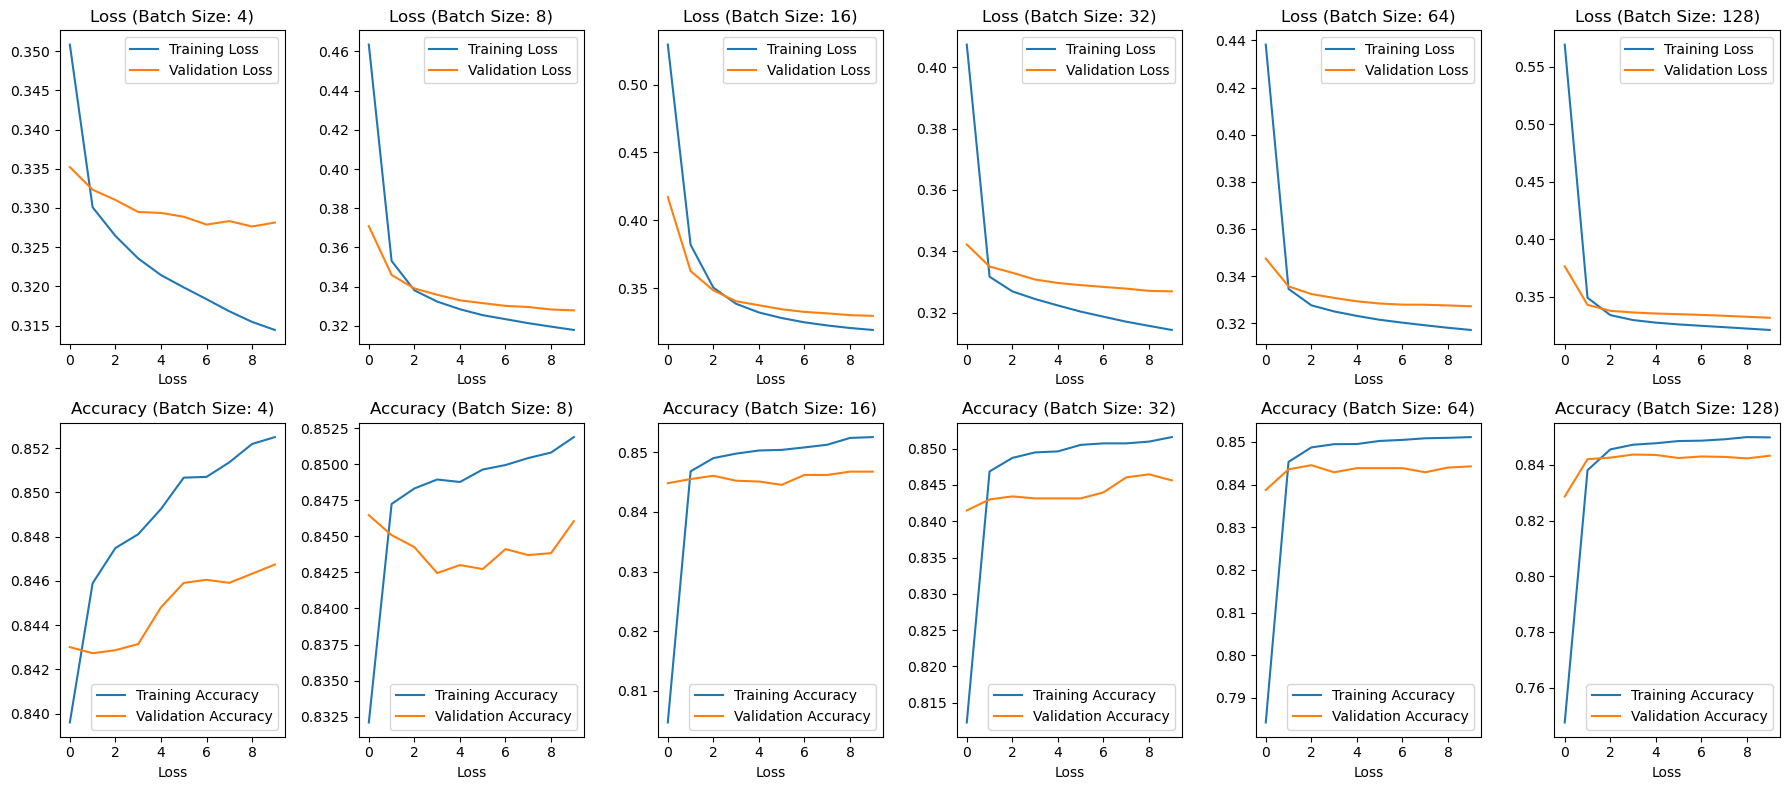

In [29]:
# tweak batch size
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=6)
fig.suptitle("Tweaking Batch Size for Funnel Model")

# get loss plots as we change batch size
batch_sizes = [4, 8, 16, 32, 64, 128]
for i, size in enumerate(batch_sizes):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_funnel_processor])),
                ("model", SKLearnClassifier(
                    model=build_funnel_model,
                    model_kwargs={
                        "layers": [16, 8, 4]
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": size,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Batch Size: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Batch Size: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

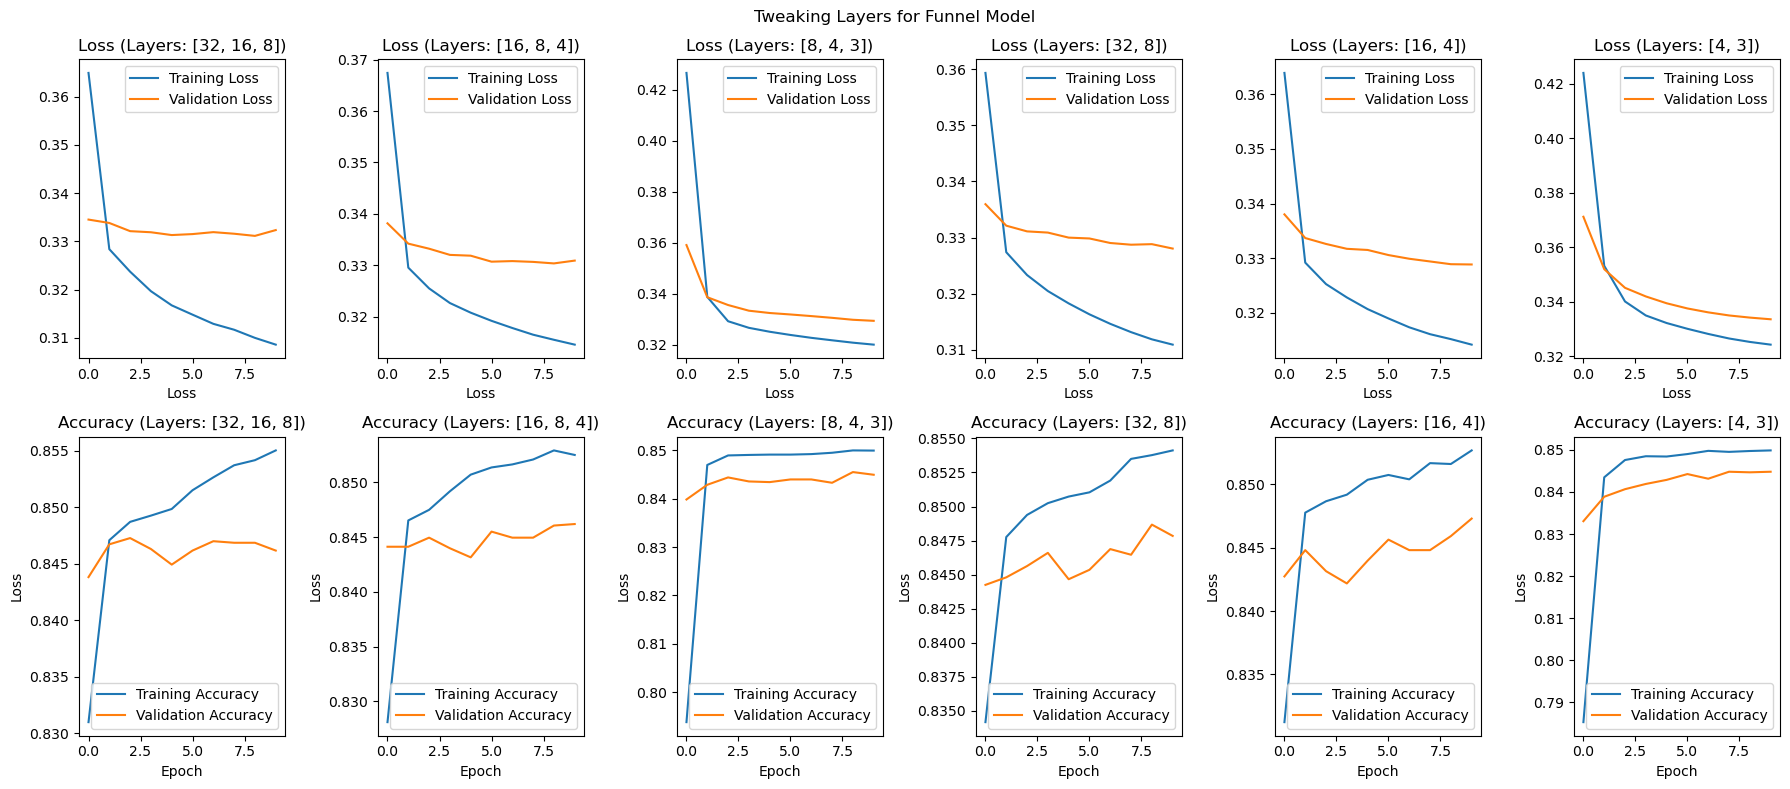

In [43]:
# tweak layers
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=6)
fig.suptitle("Tweaking Layers for Funnel Model")

# get loss plots as we change batch size
layers = [[32, 16, 8], [16, 8, 4], [8, 4, 3],
          [32, 8],     [16, 4],    [4, 3]]
for i, size in enumerate(layers):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_funnel_processor])),
                ("model", SKLearnClassifier(
                    model=build_funnel_model,
                    model_kwargs={
                        "layers": size
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": 16,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Layers: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Layers: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

## Dropout Model

In [46]:
def build_dropout_model(X, y, layers=[16, 8, 4], dropout_pct=0.3, learning_rate=0.001):
    # define input shape given post-transform training data
    n_features_in = X.shape[1]
    inputs = keras.Input(shape=(n_features_in,))

    # build out hidden layers
    hidden = inputs
    for layer_size in layers:
        # use leaky relu. we will use a dropout to regularize
        hidden = keras.layers.Dense(layer_size, activation="leaky_relu")(hidden)

    # add a dropout layer
    dropout = keras.layers.Dropout(dropout_pct)(hidden)

    # define output shape
    outputs = keras.layers.Dense(2)(dropout)

    # instantiate model
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    model.compile(
        # for some reason it breaks if i use BinaryCrossentropy
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    return model

### Find Best Preprocessor

In [33]:
# determine best processor
dropout_results = evaluate_preprocessors(
    model_builder=build_dropout_model,
    model_kwargs={"layers": [16, 8, 4], "dropout_pct": 0.3},
    fit_kwargs={
        "epochs": 10,
        "batch_size": 16,
        "validation_split": 0.2,
        "verbose": 0,
    }
)

best_dropout_processor = dropout_results.sort_values("balanced_accuracy", ascending=False).iloc[0]["processor"]
dropout_results.sort_values("balanced_accuracy", ascending=False)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step


,processor,balanced_accuracy
5,MaxAbsScaler_Poly,0.785554
3,MinMaxScaler_Poly,0.777254
2,MinMaxScaler_NoPoly,0.767540
0,StandardScaler_NoPoly,0.760919
1,StandardScaler_Poly,0.757323
4,MaxAbsScaler_NoPoly,0.755865
6,RobustScaler_NoPoly,0.708540
7,RobustScaler_Poly,0.622386


### Tweak Different Parameters

- Increasing `batch_size` seems to smooth out both train and validation curves, and results in the lowest loss at a `batch_size` of 128.
- as we expand the number of hidden layers ...
- as we grow the size of each layer

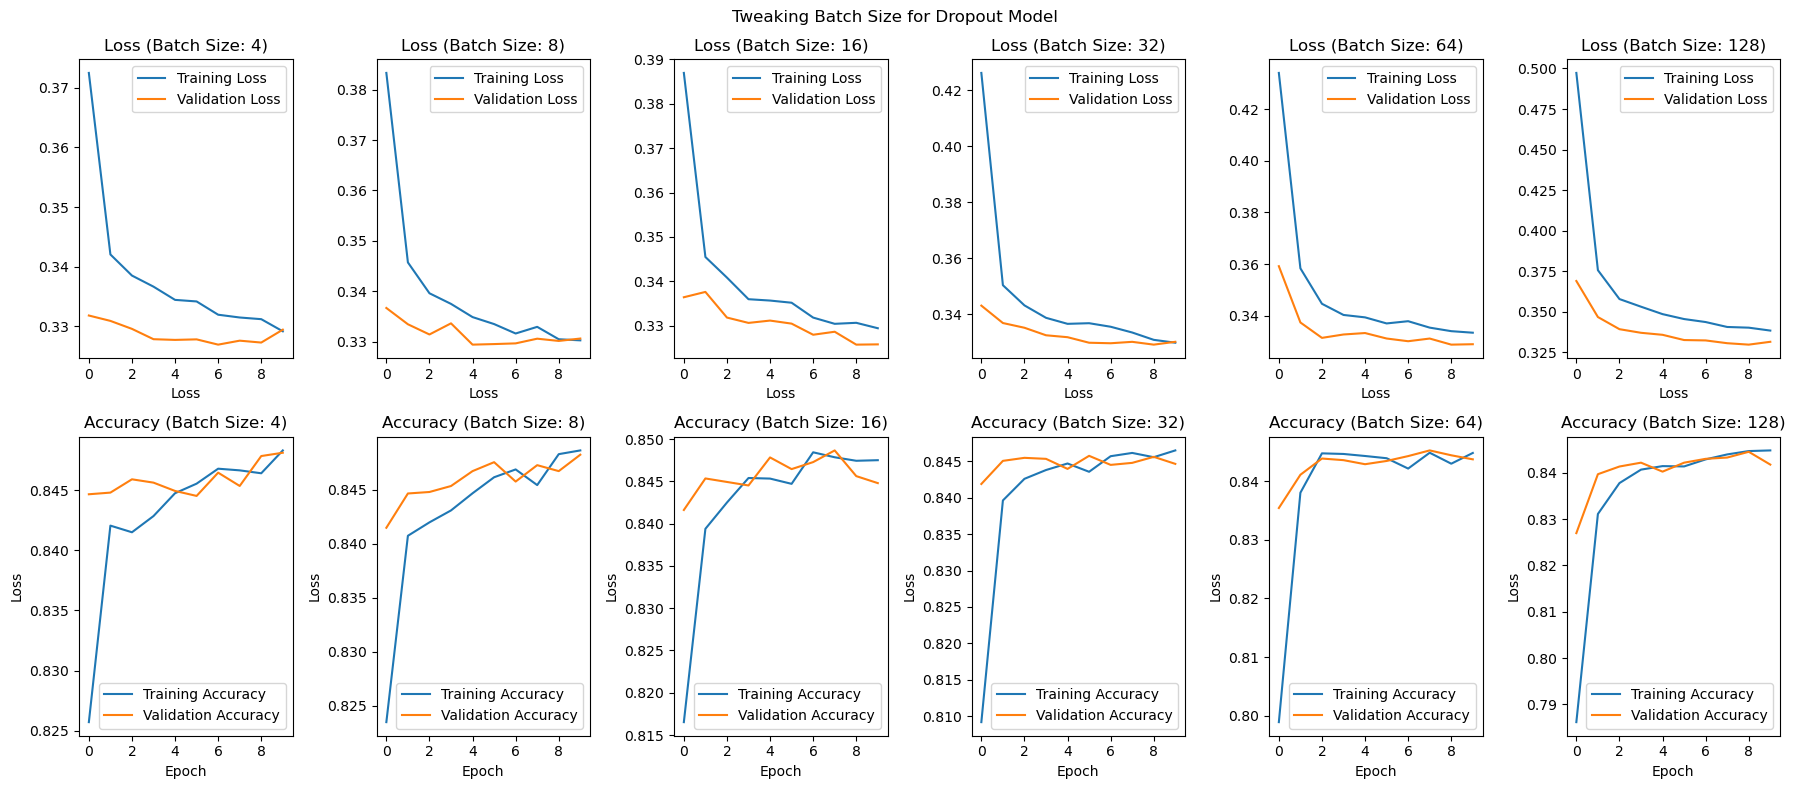

In [34]:
# tweak batch size
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=6)
fig.suptitle("Tweaking Batch Size for Dropout Model")

# get loss plots as we change batch size
batch_sizes = [4, 8, 16, 32, 64, 128]
for i, size in enumerate(batch_sizes):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_dropout_processor])),
                ("model", SKLearnClassifier(
                    model=build_dropout_model,
                    model_kwargs={
                        "layers": [16, 8, 4]
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": size,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Batch Size: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Batch Size: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

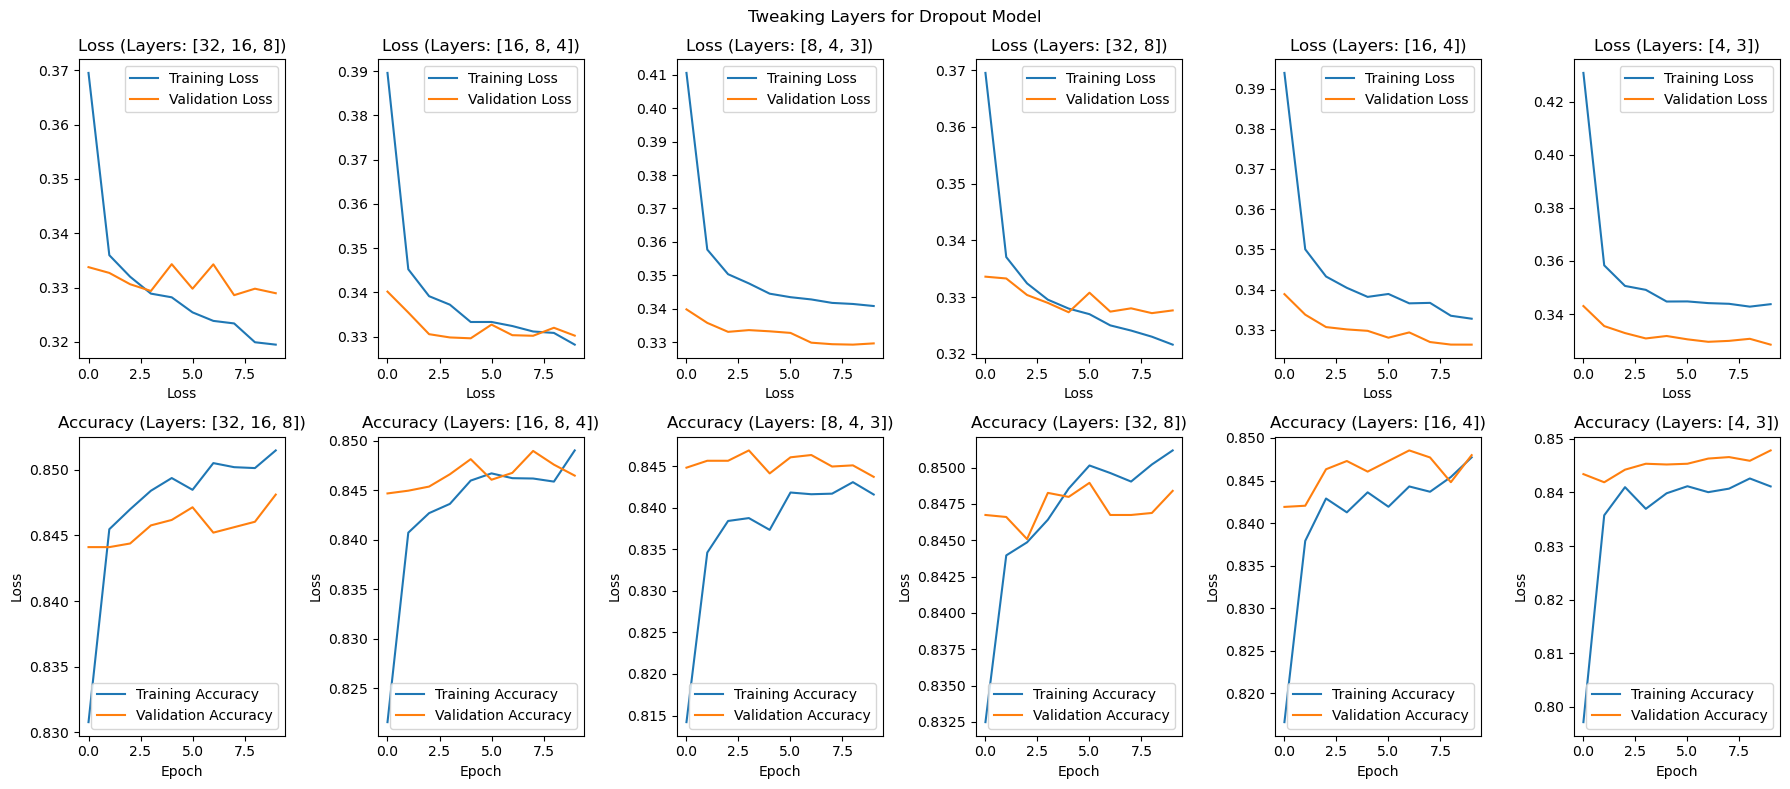

In [42]:
# tweak layers
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=6)
fig.suptitle("Tweaking Layers for Dropout Model")

# get loss plots as we change batch size
layers = [[32, 16, 8], [16, 8, 4], [8, 4, 3],
          [32, 8],     [16, 4],    [4, 3]]
for i, size in enumerate(layers):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_dropout_processor])),
                ("model", SKLearnClassifier(
                    model=build_dropout_model,
                    model_kwargs={
                        "layers": size
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": 16,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Layers: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Layers: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

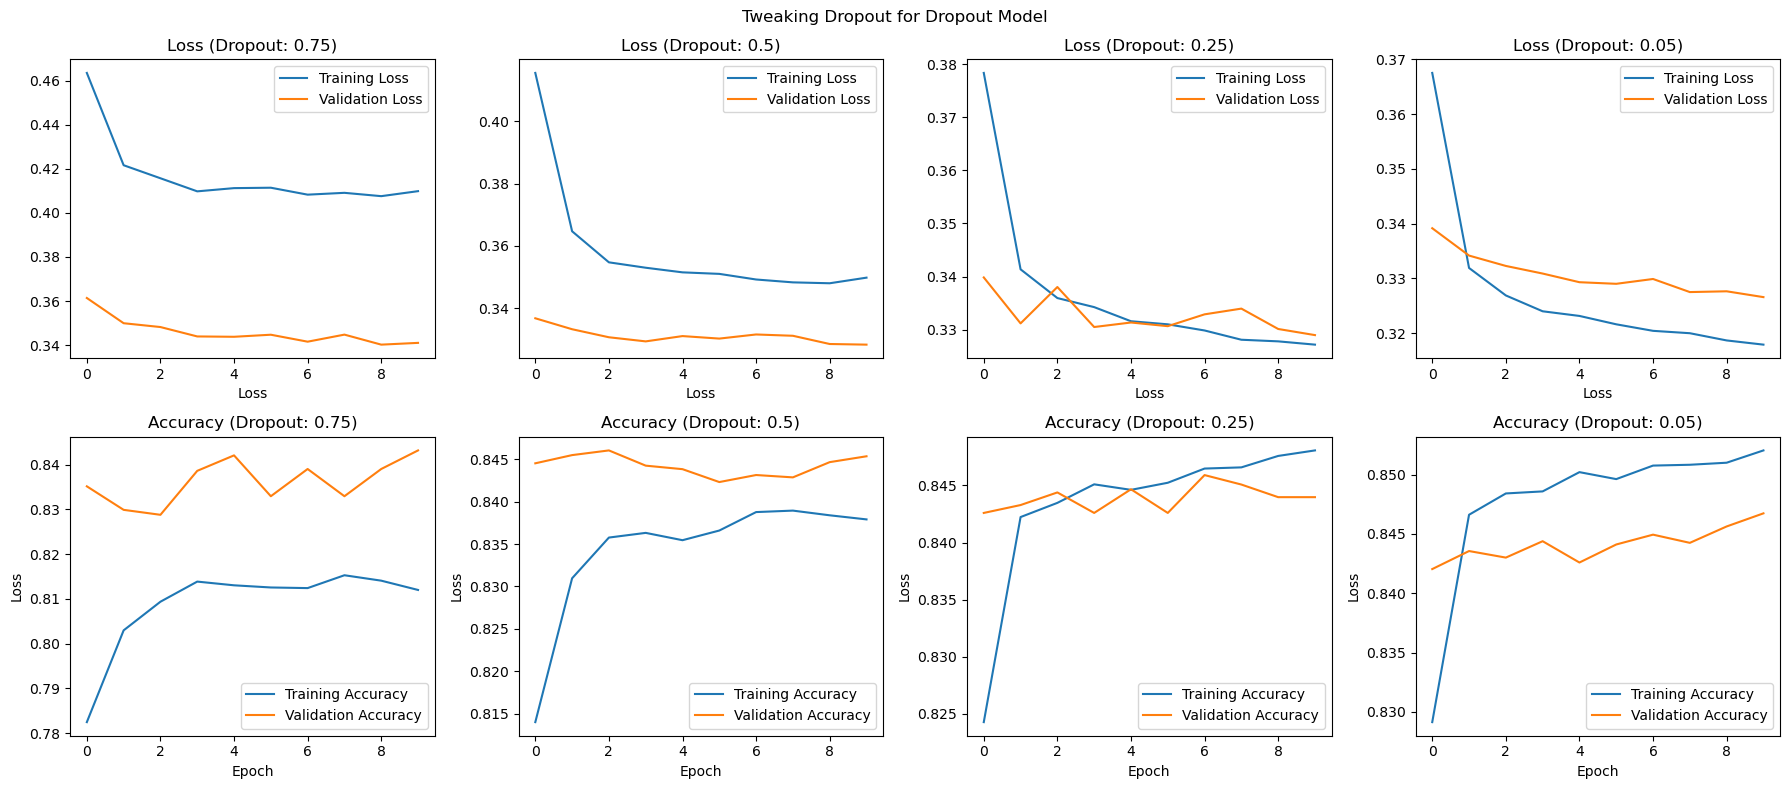

In [44]:
# tweak dropout pct
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=4)
fig.suptitle("Tweaking Dropout for Dropout Model")

# get loss plots as we change batch size
dropout_pcts = [0.75, 0.50, 0.25, 0.05]
for i, size in enumerate(dropout_pcts):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_dropout_processor])),
                ("model", SKLearnClassifier(
                    model=build_dropout_model,
                    model_kwargs={
                        "dropout_pct": size
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": 16,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Dropout: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Dropout: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

## Flat Model

In [47]:
def build_flat_model(X, y, layers=[8, 8, 8], learning_rate=0.001):
    # define input shape given post-transform training data
    n_features_in = X.shape[1]
    inputs = keras.Input(shape=(n_features_in,))

    # build out hidden layers
    hidden = inputs
    for layer_size in layers:
        hidden = keras.layers.Dense(layer_size, activation="relu")(hidden)

    # define output shape
    outputs = keras.layers.Dense(2)(hidden)

    # instantiate model
    model = keras.Model(inputs=inputs, outputs=outputs, name="flat_model")
    model.compile(
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    return model

### Find Best Preprocessor

In [37]:
# determine best processor
flat_results = evaluate_preprocessors(
    model_builder=build_flat_model,
    model_kwargs={"layers": [8, 8, 8]},
    fit_kwargs={
        "epochs": 10,
        "batch_size": 16,
        "validation_split": 0.2,
        "verbose": 0,
    }
)

best_flat_processor = flat_results.sort_values("balanced_accuracy", ascending=False).iloc[0]["processor"]
flat_results.sort_values("balanced_accuracy", ascending=False)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step


,processor,balanced_accuracy
3,MinMaxScaler_Poly,0.785815
5,MaxAbsScaler_Poly,0.785102
4,MaxAbsScaler_NoPoly,0.779986
2,MinMaxScaler_NoPoly,0.779644
0,StandardScaler_NoPoly,0.777675
1,StandardScaler_Poly,0.776377
7,RobustScaler_Poly,0.743933
6,RobustScaler_NoPoly,0.727172


### Tweak Different Parameters

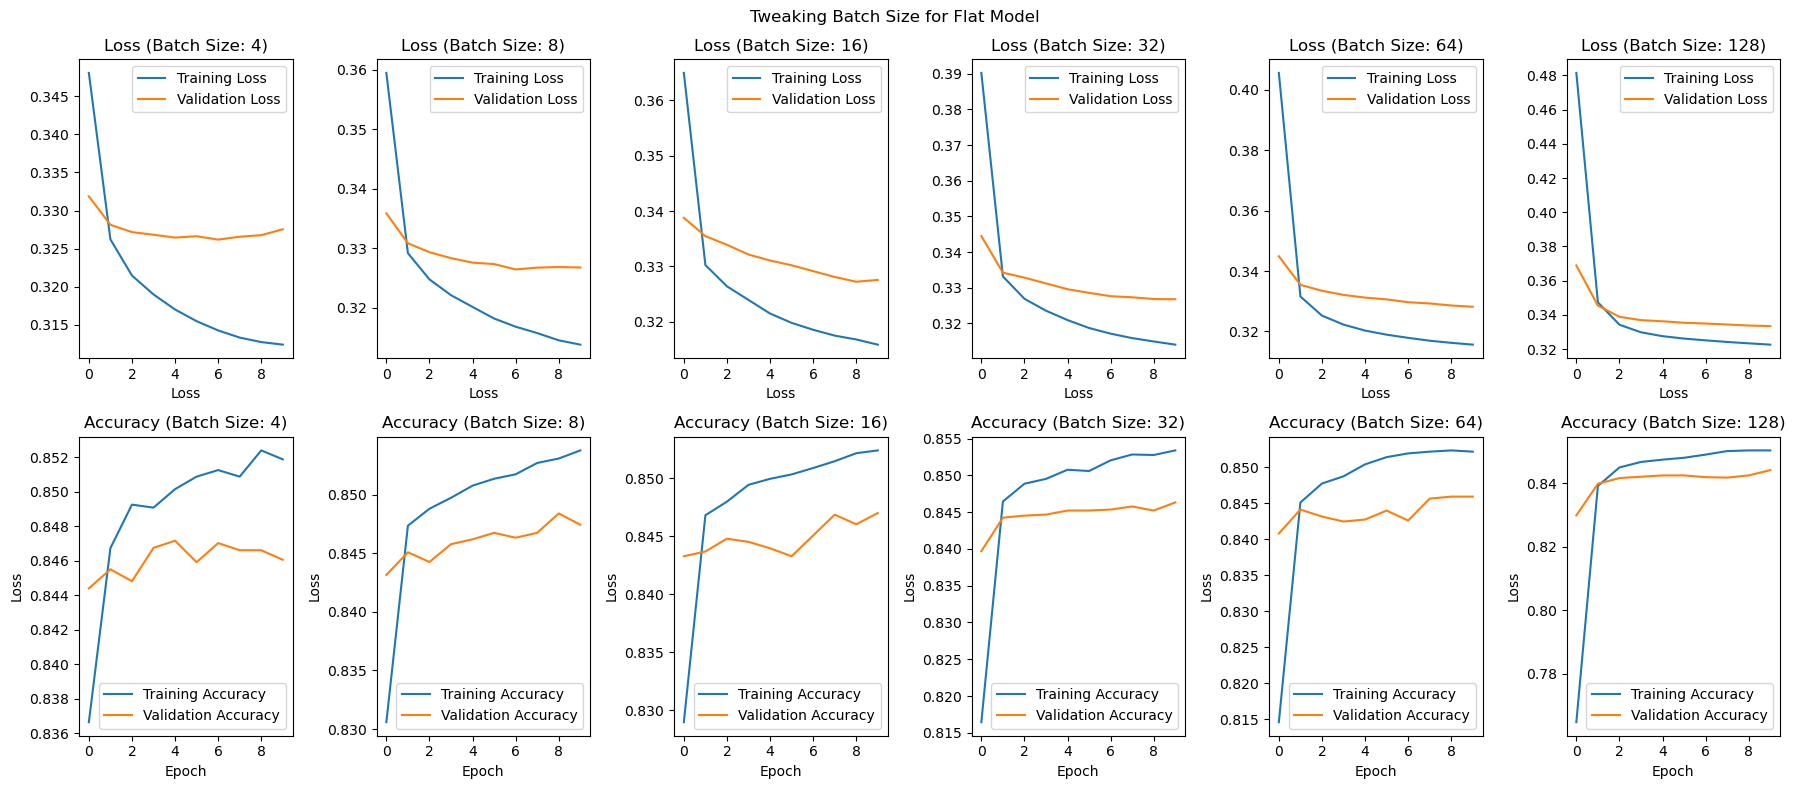

In [38]:
# tweak batch size
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=6)
fig.suptitle("Tweaking Batch Size for Flat Model")

# get loss plots as we change batch size
batch_sizes = [4, 8, 16, 32, 64, 128]
for i, size in enumerate(batch_sizes):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_flat_processor])),
                ("model", SKLearnClassifier(
                    model=build_flat_model,
                    model_kwargs={
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": size,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Batch Size: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Batch Size: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

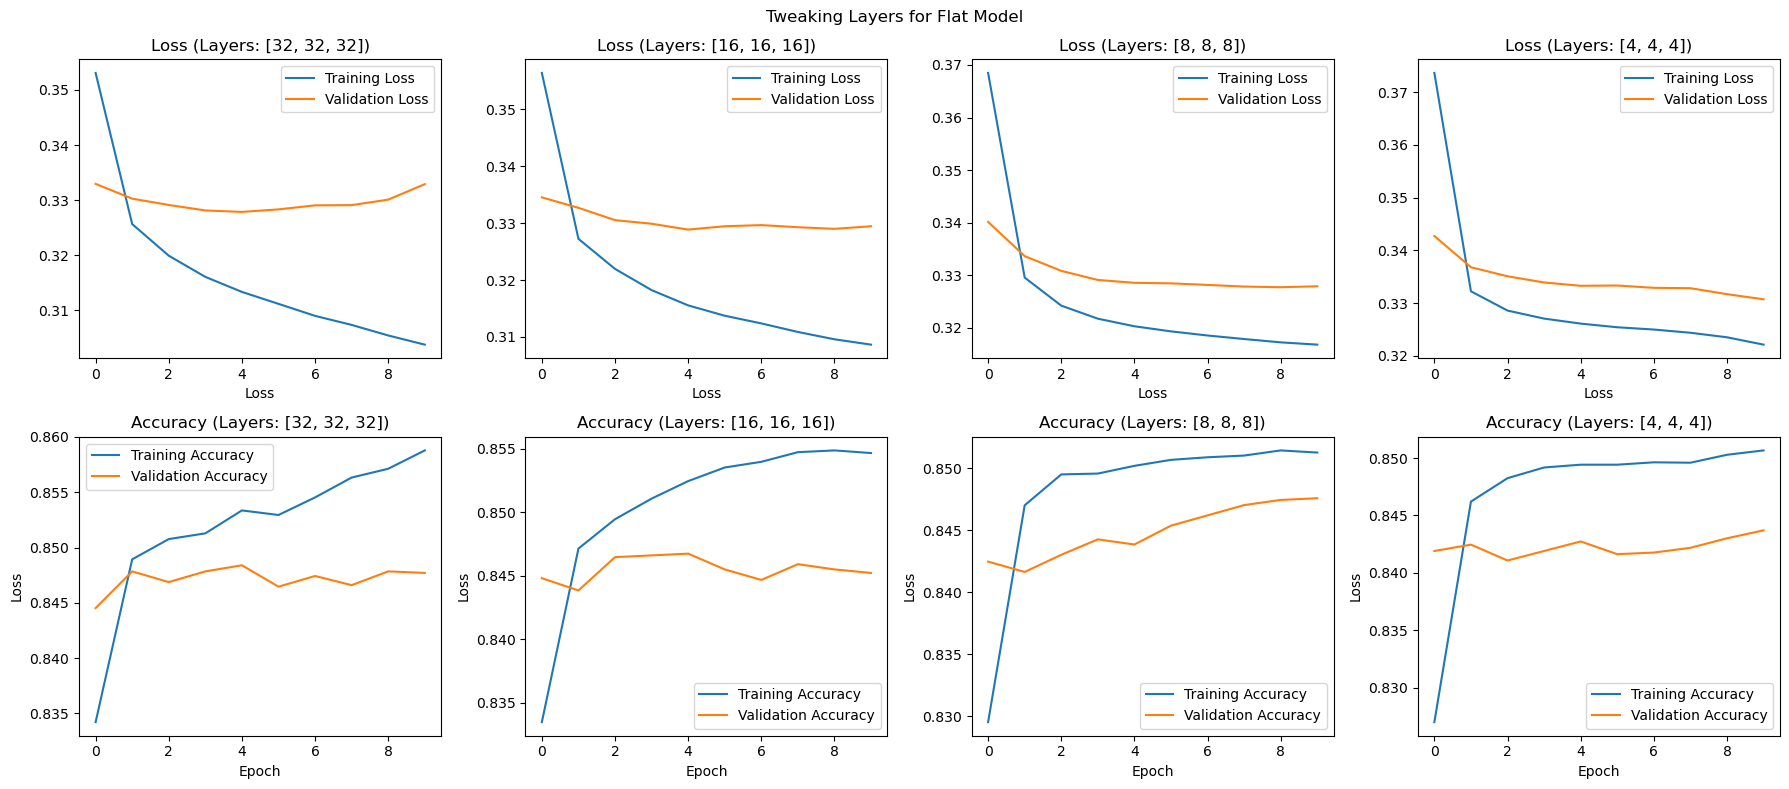

In [41]:
# tweak layers
fig, axes = plt.subplots(figsize=(18, 8), nrows=2, ncols=4)
fig.suptitle("Tweaking Layers for Flat Model")

# get loss plots as we change batch size
layers = [[32, 32, 32], [16, 16, 16], [8, 8, 8],
          [4, 4, 4]]
for i, size in enumerate(layers):
    history_callback = History()

    # train the model
    pipe = Pipeline([
                ("preprocessing", clone(preprocessors[best_flat_processor])),
                ("model", SKLearnClassifier(
                    model=build_flat_model,
                    model_kwargs={
                        "layers": size
                    },
                    fit_kwargs={
                        "epochs": 10,
                        "batch_size": 16,
                        "validation_split": 0.2,
                        "verbose": 0,
                        "callbacks": [history_callback]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # plot loss and accuracy
    history = history_callback

    axes[0, i].set_title(f"Loss (Layers: {size})")
    axes[0, i].plot(history.history['loss'], label="Training Loss")
    axes[0, i].plot(history.history['val_loss'], label="Validation Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_xlabel("Loss")
    axes[0, i].legend()

    axes[1, i].set_title(f"Accuracy (Layers: {size})")
    axes[1, i].plot(history.history['accuracy'], label="Training Accuracy")
    axes[1, i].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

fig.tight_layout()
plt.show()

# **Tuning**

## Funnel Model

In [49]:
def objective_funnel(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layer_size = trial.suggest_int("layer_size", 8, 256, step=8)

    # params
    hidden_layer_sizes = list(max(16, layer_size // (2 ** i)) for i in range(n_layers))
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    epochs = trial.suggest_int("epochs", 10, 100)
    batch_size = trial.suggest_int("batch_size", 8, 256)

    # init callbacks
    history_callback = History()
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best-performing weights
    )

    # train model
    pipe = Pipeline([
            ("preprocessing", clone(preprocessors[best_funnel_processor])),
            ("model", SKLearnClassifier(
                model=build_funnel_model,
                model_kwargs={
                    "layers": hidden_layer_sizes,
                    "learning_rate": learning_rate
                },
                fit_kwargs={
                    "epochs": epochs,
                    "batch_size": batch_size,
                    "validation_split": 0.2,
                    "verbose": 0,
                    "callbacks": [history_callback, early_stop]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # evaluate via validation loss
    return min(history_callback.history["val_loss"])

# run the study
sampler = optuna.samplers.TPESampler(seed=42)
study_funnel = optuna.create_study(direction="minimize", study_name="funnel", sampler=sampler)
study_funnel.optimize(objective_funnel, n_trials=50)

[I 2026-05-15 14:17:20,706] A new study created in memory with name: funnel


ERROR! Session/line number was not unique in database. History logging moved to new session 1066


[I 2026-05-15 14:17:28,384] Trial 0 finished with value: 0.33559828996658325 and parameters: {'n_layers': 2, 'layer_size': 248, 'learning_rate': 0.0029106359131330704, 'epochs': 64, 'batch_size': 46}. Best is trial 0 with value: 0.33559828996658325.
[I 2026-05-15 14:17:33,226] Trial 1 finished with value: 0.33081090450286865 and parameters: {'n_layers': 1, 'layer_size': 16, 'learning_rate': 0.005399484409787433, 'epochs': 64, 'batch_size': 184}. Best is trial 1 with value: 0.33081090450286865.
[I 2026-05-15 14:17:42,903] Trial 2 finished with value: 0.3302849531173706 and parameters: {'n_layers': 1, 'layer_size': 256, 'learning_rate': 0.004622589001020831, 'epochs': 29, 'batch_size': 53}. Best is trial 2 with value: 0.3302849531173706.
[I 2026-05-15 14:17:53,681] Trial 3 finished with value: 0.32527217268943787 and parameters: {'n_layers': 1, 'layer_size': 80, 'learning_rate': 0.0011207606211860567, 'epochs': 49, 'batch_size': 80}. Best is trial 3 with value: 0.32527217268943787.
[I 20

## Dropout Model

In [50]:
def objective_dropout(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layer_size = trial.suggest_int("layer_size", 8, 256, step=8)

    # params
    hidden_layer_sizes = list(max(16, layer_size // (2 ** i)) for i in range(n_layers))
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    epochs = trial.suggest_int("epochs", 10, 100)
    batch_size = trial.suggest_int("batch_size", 8, 256)
    dropout_pct = trial.suggest_float("dropout_pct", 0, 0.8)

    # init callbacks
    history_callback = History()
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best-performing weights
    )

    # train model
    pipe = Pipeline([
            ("preprocessing", clone(preprocessors[best_dropout_processor])),
            ("model", SKLearnClassifier(
                model=build_dropout_model,
                model_kwargs={
                    "layers": hidden_layer_sizes,
                    "learning_rate": learning_rate,
                    "dropout_pct": dropout_pct
                },
                fit_kwargs={
                    "epochs": epochs,
                    "batch_size": batch_size,
                    "validation_split": 0.2,
                    "verbose": 0,
                    "callbacks": [history_callback, early_stop]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # evaluate via validation loss
    return min(history_callback.history["val_loss"])

# run the study
sampler = optuna.samplers.TPESampler(seed=42)
study_dropout = optuna.create_study(direction="minimize", study_name="dropout", sampler=sampler)
study_dropout.optimize(objective_dropout, n_trials=50)

[I 2026-05-15 14:24:12,236] A new study created in memory with name: dropout
[I 2026-05-15 14:24:22,034] Trial 0 finished with value: 0.3360736668109894 and parameters: {'n_layers': 2, 'layer_size': 248, 'learning_rate': 0.0029106359131330704, 'epochs': 64, 'batch_size': 46, 'dropout_pct': 0.12479561626896213}. Best is trial 0 with value: 0.3360736668109894.
[I 2026-05-15 14:24:47,825] Trial 1 finished with value: 0.3303283751010895 and parameters: {'n_layers': 1, 'layer_size': 224, 'learning_rate': 0.0015930522616241021, 'epochs': 74, 'batch_size': 13, 'dropout_pct': 0.7759278817295955}. Best is trial 1 with value: 0.3303283751010895.
[I 2026-05-15 14:24:59,834] Trial 2 finished with value: 0.3258044719696045 and parameters: {'n_layers': 4, 'layer_size': 56, 'learning_rate': 0.0002310201887845295, 'epochs': 26, 'batch_size': 83, 'dropout_pct': 0.4198051453057903}. Best is trial 2 with value: 0.3258044719696045.
[I 2026-05-15 14:25:07,123] Trial 3 finished with value: 0.324402302503585

## Flat Model

In [51]:
def objective_flat(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layer_size = trial.suggest_int("layer_size", 8, 256, step=8)

    # params
    hidden_layer_sizes = list(layer_size for _ in range(n_layers))
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    epochs = trial.suggest_int("epochs", 10, 100)
    batch_size = trial.suggest_int("batch_size", 8, 256)

    # init callbacks
    history_callback = History()
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best-performing weights
    )

    # train model
    pipe = Pipeline([
            ("preprocessing", clone(preprocessors[best_flat_processor])),
            ("model", SKLearnClassifier(
                model=build_flat_model,
                model_kwargs={
                    "layers": hidden_layer_sizes,
                    "learning_rate": learning_rate,
                },
                fit_kwargs={
                    "epochs": epochs,
                    "batch_size": batch_size,
                    "validation_split": 0.2,
                    "verbose": 0,
                    "callbacks": [history_callback, early_stop]
                    }
                ))
            ])

    pipe.fit(X_train, y_train)

    # evaluate via validation loss
    return min(history_callback.history["val_loss"])

# run the study
sampler = optuna.samplers.TPESampler(seed=42)
study_flat = optuna.create_study(direction="minimize", study_name="flat", sampler=sampler)
study_flat.optimize(objective_flat, n_trials=50)

[I 2026-05-15 14:32:58,490] A new study created in memory with name: flat
[I 2026-05-15 14:33:07,622] Trial 0 finished with value: 0.3322811722755432 and parameters: {'n_layers': 2, 'layer_size': 248, 'learning_rate': 0.0029106359131330704, 'epochs': 64, 'batch_size': 46}. Best is trial 0 with value: 0.3322811722755432.
[I 2026-05-15 14:33:11,659] Trial 1 finished with value: 0.33064448833465576 and parameters: {'n_layers': 1, 'layer_size': 16, 'learning_rate': 0.005399484409787433, 'epochs': 64, 'batch_size': 184}. Best is trial 1 with value: 0.33064448833465576.
[I 2026-05-15 14:33:20,231] Trial 2 finished with value: 0.3294909596443176 and parameters: {'n_layers': 1, 'layer_size': 256, 'learning_rate': 0.004622589001020831, 'epochs': 29, 'batch_size': 53}. Best is trial 2 with value: 0.3294909596443176.
[I 2026-05-15 14:33:27,846] Trial 3 finished with value: 0.32274308800697327 and parameters: {'n_layers': 1, 'layer_size': 80, 'learning_rate': 0.0011207606211860567, 'epochs': 49, '

# **Evaluation**

In [52]:
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best-performing weights
    )

In [53]:
# train final funnel
funnel_params = study_funnel.best_params

hidden_layer_sizes = list(max(16, funnel_params["layer_size"] // (2 ** i)) for i in range(funnel_params["n_layers"]))
final_funnel = Pipeline([
        ("preprocessing", clone(preprocessors[best_funnel_processor])),
        ("model", SKLearnClassifier(
            model=build_funnel_model,
            model_kwargs={
                "layers": hidden_layer_sizes,
                "learning_rate": funnel_params["learning_rate"]
            },
            fit_kwargs={
                "epochs": funnel_params["epochs"],
                "batch_size": funnel_params["batch_size"],
                "validation_split": 0.2,
                "verbose": 0,
                "callbacks": [early_stop]
            }
    ))
])

final_funnel.fit(X_train, y_train)
y_preds = final_funnel.predict(X_test)

funnel_score = balanced_accuracy_score(y_test, y_preds)
print(f"Funnel Balanced Accuracy (Holdout): {funnel_score:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step
Funnel Balanced Accuracy (Holdout): 0.7738


In [54]:
# train final dropout
dropout_params = study_dropout.best_params

hidden_layer_sizes = list(max(16, dropout_params["layer_size"] // (2 ** i)) for i in range(dropout_params["n_layers"]))
final_dropout = Pipeline([
        ("preprocessing", clone(preprocessors[best_dropout_processor])),
        ("model", SKLearnClassifier(
            model=build_dropout_model,
            model_kwargs={
                "layers": hidden_layer_sizes,
                "learning_rate": dropout_params["learning_rate"],
                "dropout_pct": dropout_params["dropout_pct"]
            },
            fit_kwargs={
                "epochs": dropout_params["epochs"],
                "batch_size": dropout_params["batch_size"],
                "validation_split": 0.2,
                "verbose": 0,
                "callbacks": [early_stop]
            }
    ))
])

final_dropout.fit(X_train, y_train)
y_preds = final_dropout.predict(X_test)

dropout_score = balanced_accuracy_score(y_test, y_preds)
print(f"Dropout Balanced Accuracy (Holdout): {dropout_score:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
Dropout Balanced Accuracy (Holdout): 0.7826


In [56]:
# train final flat
flat_params = study_flat.best_params

hidden_layer_sizes = list(flat_params["layer_size"] for _ in range(flat_params["n_layers"]))
final_flat = Pipeline([
        ("preprocessing", clone(preprocessors[best_flat_processor])),
        ("model", SKLearnClassifier(
            model=build_flat_model,
            model_kwargs={
                "layers": hidden_layer_sizes,
                "learning_rate": flat_params["learning_rate"],
            },
            fit_kwargs={
                "epochs": flat_params["epochs"],
                "batch_size": flat_params["batch_size"],
                "validation_split": 0.2,
                "verbose": 0,
                "callbacks": [early_stop]
            }
    ))
])

final_flat.fit(X_train, y_train)
y_preds = final_flat.predict(X_test)

flat_score = balanced_accuracy_score(y_test, y_preds)
print(f"Flat Balanced Accuracy (Holdout): {flat_score:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
Flat Balanced Accuracy (Holdout): 0.7522


# **Discussion**

The best model will be the dropout model using the MaxAbsScaler_Poly preprocessing pipeline. It outperformed the next best model by an accuracy of ~0.01. The flat performed worst, with an accuracy 0.30 lower than the dropout.

The dropout model likely performed best with polynomial features because of the random suppression of certain features, allowing the model to learn multiple or better pathways to achieve a more accurate prediction. Providing it with many features and 17 epochs to train allowed it to achieve the best score.

The funnel model also performed well. I expect the funnel architecture to "distill" features as data filters through the hidden layers. As we see in the experimenting with layer width and depth, adding more layers or making them bigger doesn't always result in better performance. As with most ML problems, there is always a sweet spot somewhere in the middle.

In [57]:
pd.DataFrame({
    "final_model": ["funnel", "dropout", "flat"],
    "score": [funnel_score, dropout_score, flat_score]
})

,final_model,score
0,funnel,0.773777
1,dropout,0.782570
2,flat,0.752162


## Personal Workflow

1. Create multiple preprocessing pipelines. Try different transformations and scalers. Create a polynomial feature version for each in lieu of manual feature engineering.
2. Define three complementary baseline models: Funnel, Dropout, and Flat. Train each model on every preprocessing pipeline and use the best performing preprocessor given the model for downstream tasks.
3. Here is where I would opt to do an error analysis. Now that we know which features we will use for the final model, we should see where each model struggles. This can inform hyperparameter ranges in finetuning or result in manual feature creation to give the model a kickstart. Finally, an error analysis can tell us if our models are complementary; they should be stacked to improve performance.
4. Finetune each model: Layers and layer sizes, learning rates, batch sizes, and epochs.
5. Evaluate each model on the holdout dataset.